# Graph-Based Risk Mapping 

Install dependencies first:
```
pip install -r ../requirements.txt
```

In [2]:
# Core
import numpy as np
import pandas as pd
import scipy
import geopandas as gpd

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Load Data

In [5]:
telemetry = pd.read_csv("../data/Florida_Panther_Telemetry.csv")
telemetry.head()

,X,Y,OBJECTID,FLGTDATE,CATNUMBER,TIME,UTM83EAST,UTM83NORTH,AGENCY,COMMENTS,last_edited_date
0,632846.8222,233310.8165,1,2024/02/05 00:00:00+00,FP262,7:38,433141,2885197,FWC,NaN,2025/08/22 19:21:50+00
1,640120.2235,266243.5851,2,2024/02/05 00:00:00+00,FP265,7:58,441216,2917876,FWC,NaN,2025/08/22 19:21:50+00
2,639150.7655,275216.5430,3,2024/02/05 00:00:00+00,FP266,8:07,440462,2926850,FWC,NaN,2025/08/22 19:21:50+00
3,638189.4688,264835.6272,4,2024/02/05 00:00:00+00,FP267,7:51,439249,2916518,FWC,NaN,2025/08/22 19:21:50+00
4,632805.4293,232123.0745,5,2024/02/08 00:00:00+00,FP262,7:31,433071,2884013,FWC,NaN,2025/08/22 19:21:50+00


In [3]:
mortality = pd.read_csv("../data/Florida_Panther_Mortality.csv")
mortality.head()

,X,Y,OBJECTID,PANTHERID,SEX,AGE,LOCATION,CAUSE,YEAR,Date,PANTHERID2,MORTID,AGE_UNITS,COUNTY,last_edited_date
0,626465.5656,260632.3932,1,UCFP478,Male,2.25,Bonita Beach Road in the median turn lane. Lo...,Vehicular trauma,2024,2024/12/26 00:00:00+00,NaN,MN-01264,Years,Lee,2025/08/22 19:21:02+00
1,650092.3328,264970.7258,2,UCFP479,Male,1.75,"South shoulder of Immokalee Road, 3.2km east o...",Vehicular trauma,2025,2025/01/10 00:00:00+00,NaN,MN-01267,Years,Collier,2025/08/22 19:21:02+00
2,696947.6124,267377.1117,3,UCFP480,Female,10.5,Found on the side of CR-833 1/4 of a mile sout...,Vehicular trauma,2025,2025/02/24 00:00:00+00,NaN,MN-01268,Years,Hendry,2025/08/22 19:21:02+00
3,641054.3979,302851.9650,4,UCFP481,Male,1.5,Median on SR-80 East of intersection with Silk...,Vehicular trauma,2025,2025/03/06 00:00:00+00,NaN,MN-01269,Years,Collier,2025/08/22 19:21:02+00
4,655215.8276,280821.1504,5,UCFP482,Male,4.5,"SR29, 2.5km north of the junction with SR82",Vehicular trauma,2025,2025/03/10 00:00:00+00,NaN,MN-01270,Years,Collier,2025/08/22 19:21:02+00


## Load geoJSON Data

### Florida Panther Telemetry Data

In [51]:
telemetry_gdf = gpd.read_file("../geoJSON/Florida_Panther_Telemetry.geojson")
telemetry_gdf.head()

,OBJECTID,FLGTDATE,CATNUMBER,TIME,UTM83EAST,UTM83NORTH,AGENCY,COMMENTS,last_edited_date,geometry
0,1,2024-02-05 00:00:00+00:00,FP262,7:38,433141,2885197,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.66854 26.08436)
1,2,2024-02-05 00:00:00+00:00,FP265,7:58,441216,2917876,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.58929 26.37977)
2,3,2024-02-05 00:00:00+00:00,FP266,8:07,440462,2926850,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.59726 26.46076)
3,4,2024-02-05 00:00:00+00:00,FP267,7:51,439249,2916518,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.60894 26.36743)
4,5,2024-02-08 00:00:00+00:00,FP262,7:31,433071,2884013,FWC,NaN,2025-08-22 19:21:50+00:00,POINT (-81.66918 26.07366)


### Florida Panther Mortality Data

In [4]:
mortality_gdf = gpd.read_file("../geoJSON/Florida_Panther_Mortality.geojson")
mortality_gdf.head()

,OBJECTID,PANTHERID,SEX,AGE,LOCATION,CAUSE,YEAR,Date,PANTHERID2,MORTID,AGE_UNITS,COUNTY,last_edited_date,geometry
0,1,UCFP478,Male,2.25,Bonita Beach Road in the median turn lane. Lo...,Vehicular trauma,2024,2024-12-26 00:00:00+00:00,NaN,MN-01264,Years,Lee,2025-08-22 19:21:02+00:00,POINT (-81.72738 26.33156)
1,2,UCFP479,Male,1.75,"South shoulder of Immokalee Road, 3.2km east o...",Vehicular trauma,2025,2025-01-10 00:00:00+00:00,NaN,MN-01267,Years,Collier,2025-08-22 19:21:02+00:00,POINT (-81.48946 26.36651)
2,3,UCFP480,Female,10.5,Found on the side of CR-833 1/4 of a mile sout...,Vehicular trauma,2025,2025-02-24 00:00:00+00:00,NaN,MN-01268,Years,Hendry,2025-08-22 19:21:02+00:00,POINT (-81.01869 26.37879)
3,4,UCFP481,Male,1.5,Median on SR-80 East of intersection with Silk...,Vehicular trauma,2025,2025-03-06 00:00:00+00:00,NaN,MN-01269,Years,Collier,2025-08-22 19:21:02+00:00,POINT (-81.57268 26.70933)
4,5,UCFP482,Male,4.5,"SR29, 2.5km north of the junction with SR82",Vehicular trauma,2025,2025-03-10 00:00:00+00:00,NaN,MN-01270,Years,Collier,2025-08-22 19:21:02+00:00,POINT (-81.43473 26.50833)


## Exploratory Data Analysis

In [8]:
mortality.describe()

,X,Y,OBJECTID,YEAR
count,691.000000,6.910000e+02,691.000000,691.000000
mean,662941.804588,2.675443e+05,346.000000,2011.054993
std,28323.423394,5.363821e+04,199.618803,10.119425
min,557969.275600,1.530863e+05,1.000000,1949.000000
25%,641849.024400,2.421530e+05,173.500000,2006.000000
50%,663703.880100,2.623029e+05,346.000000,2013.000000
75%,679935.807100,2.805730e+05,518.500000,2018.000000
max,850348.802000,1.009166e+06,691.000000,2025.000000


In [6]:
telemetry.describe()

,X,Y,OBJECTID,UTM83EAST,UTM83NORTH
count,112802.000000,112802.000000,112802.00000,112802.000000,1.128020e+05
mean,680980.034190,235510.214416,56401.50000,481373.827166,2.886227e+06
std,26889.032451,33561.563490,32563.27687,26404.271211,3.390056e+04
min,616388.543800,138652.649800,1.00000,418121.000000,2.788403e+06
25%,662015.421350,222705.622200,28201.25000,462721.000000,2.873404e+06
50%,676359.448350,243304.603350,56401.50000,477021.000000,2.894504e+06
75%,697455.132325,253902.063275,84601.75000,497921.000000,2.904542e+06
max,764040.567300,480679.257700,112802.00000,562718.000000,3.131705e+06


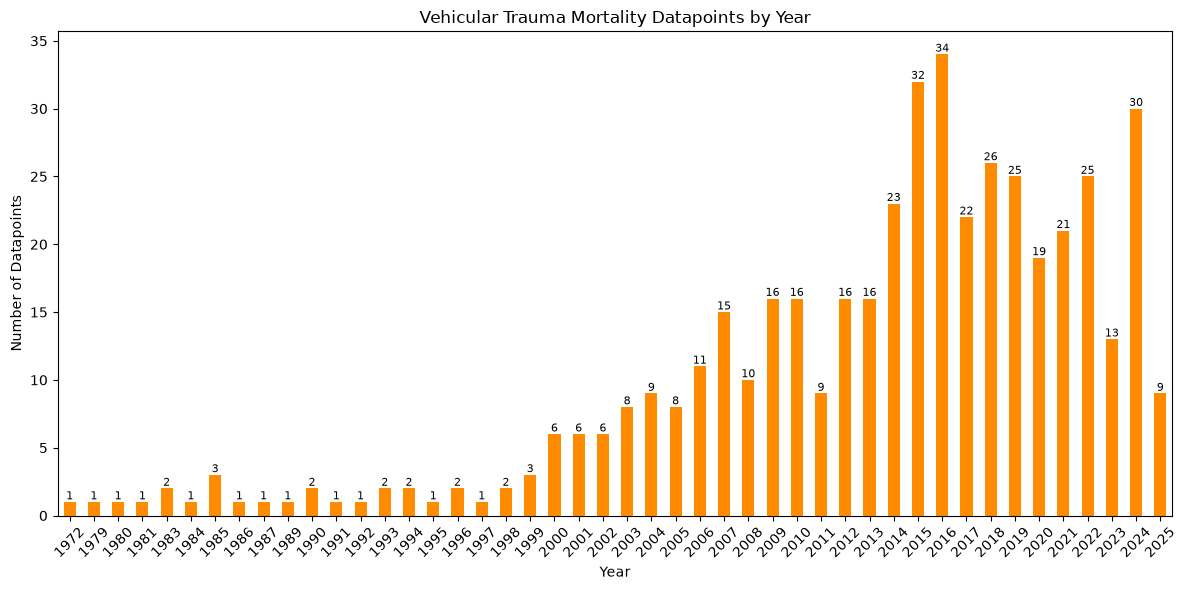

In [8]:
# Plot the number of mortality datapoints by year (Vehicular trauma only)
def get_year(df):
    year_col = next((c for c in df.columns if c.lower() == "year"), None)
    if year_col:
        return pd.to_numeric(df[year_col], errors="coerce")

    date_col = next(
        (c for c in df.columns if "date" in c.lower() or "time" in c.lower()),
        None
    )
    if date_col:
        return pd.to_datetime(df[date_col], errors="coerce").dt.year

    raise ValueError("No year or date column found.")

mortality_vehicular = mortality[mortality["CAUSE"] == "Vehicular trauma"]
mortality_by_year = get_year(mortality_vehicular).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 6))

bars = mortality_by_year.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Vehicular Trauma Mortality Datapoints by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Datapoints")

for bar in bars.patches:
    ax.annotate(
        f"{int(bar.get_height())}",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center", va="bottom", fontsize=8
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

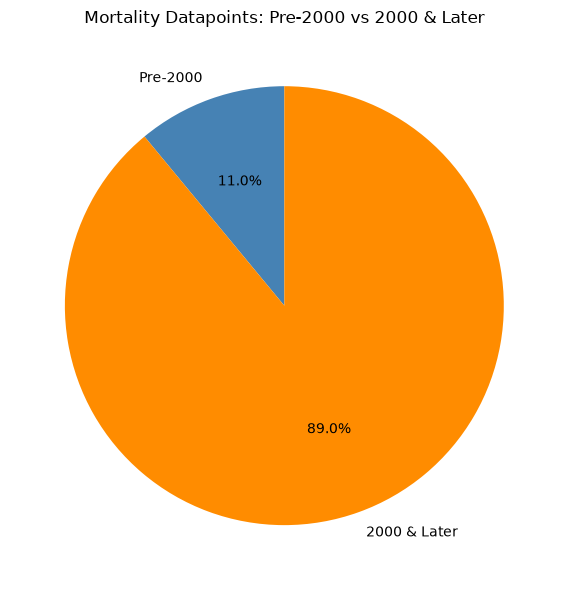

In [7]:
# Plot the distribution of mortality datapoints pre- and post-2000
mortality_years = get_year(mortality)

period_counts = pd.Series({
    "Pre-2000": (mortality_years < 2000).sum(),
    "2000 & Later": (mortality_years >= 2000).sum(),
})

fig, ax = plt.subplots(figsize=(6, 6))

period_counts.plot(
    kind="pie",
    ax=ax,
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "darkorange"],
    ylabel=""
)
ax.set_title("Mortality Datapoints: Pre-2000 vs 2000 & Later")
plt.tight_layout()
plt.show()

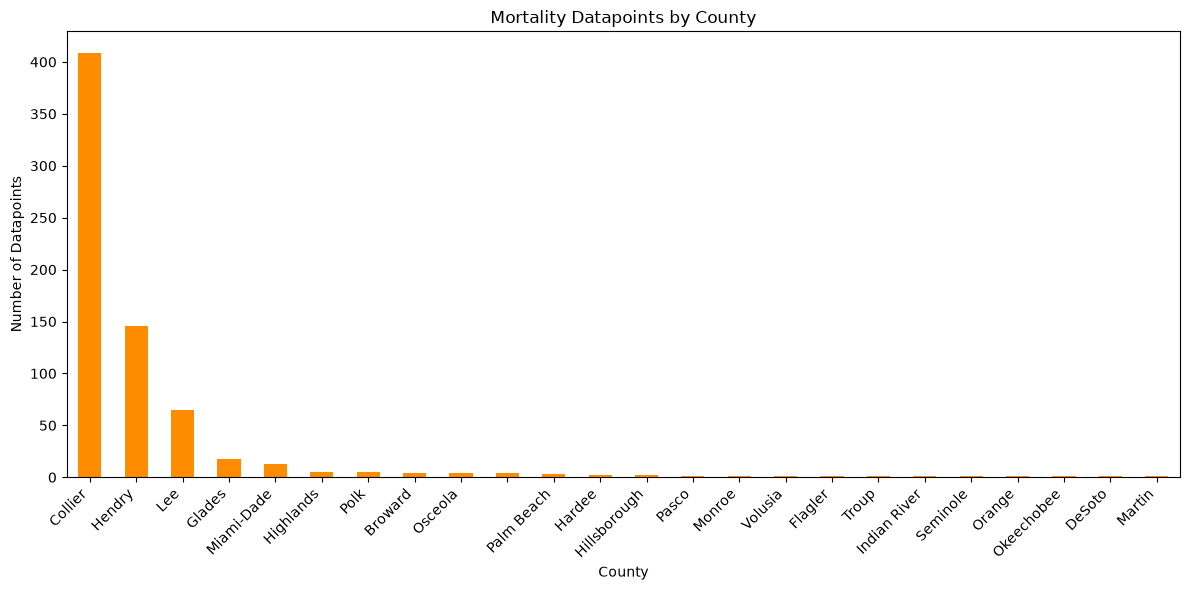

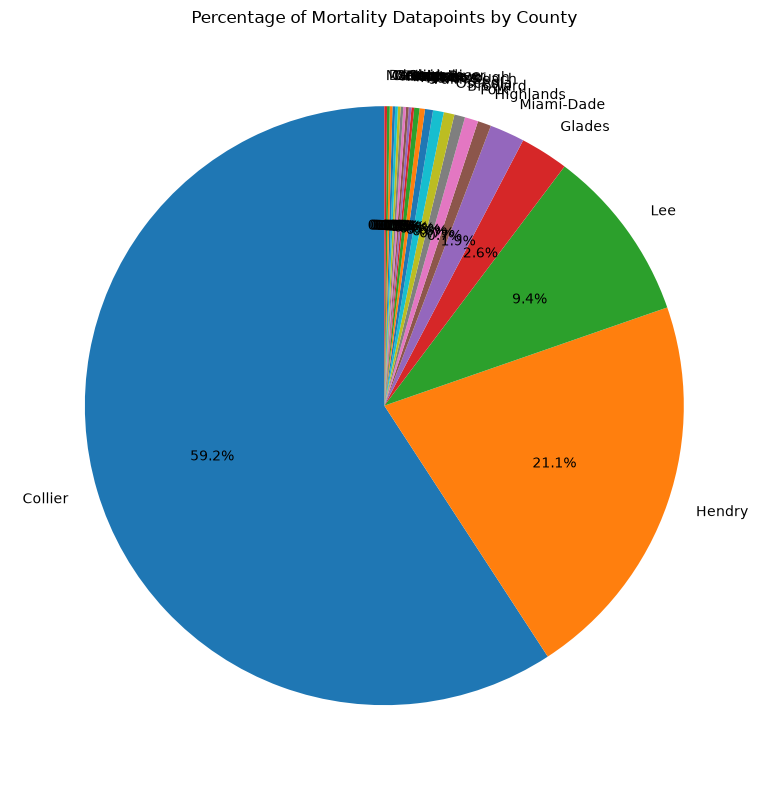

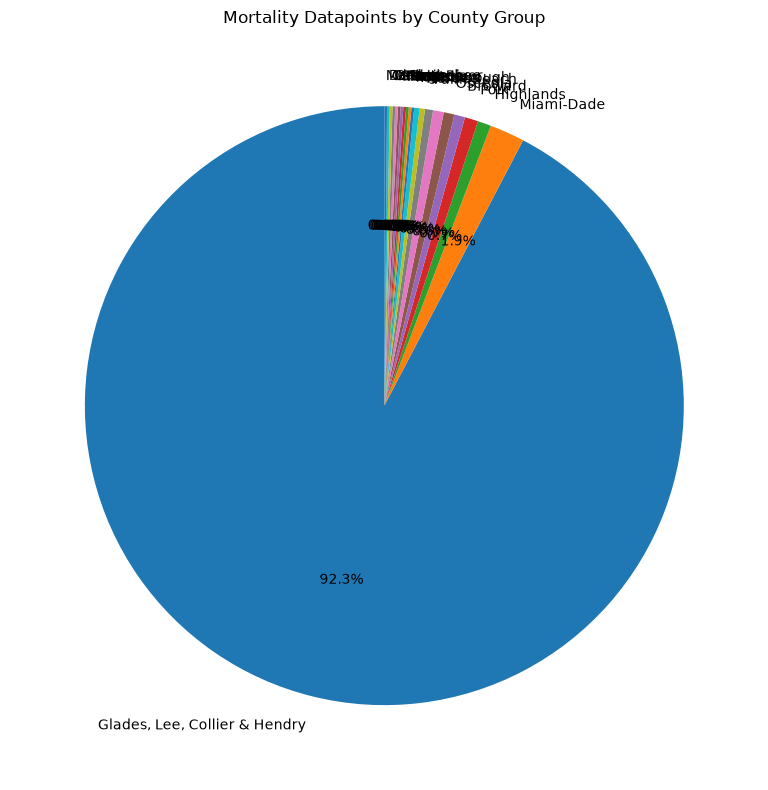

In [5]:
# Plot the number of telemetry and mortality datapoints by year
def get_year(df):
    year_col = next((c for c in df.columns if c.lower() == "year"), None)
    if year_col:
        return pd.to_numeric(df[year_col], errors="coerce")

    date_col = next(
        (c for c in df.columns if "date" in c.lower() or "time" in c.lower()),
        None
    )
    if date_col:
        return pd.to_datetime(df[date_col], errors="coerce").dt.year

    raise ValueError("No year or date column found.")

# Plot mortality datapoints by county
mortality_by_county = (
    mortality["COUNTY"]
    .fillna("Unknown")
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))

mortality_by_county.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Mortality Datapoints by County")
ax.set_xlabel("County")
ax.set_ylabel("Number of Datapoints")

ax.set_xticklabels(mortality_by_county.index, rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
mortality_by_county.plot(
    kind="pie",
    ax=ax,
    autopct="%1.1f%%",
    startangle=90,
    ylabel=""
)
ax.set_title("Percentage of Mortality Datapoints by County")
plt.tight_layout()
plt.show()

combined_counties = ["Glades", "Lee", "Collier", "Hendry"]

combined_count = mortality_by_county[
    mortality_by_county.index.isin(combined_counties)
].sum()

combined_pie_data = mortality_by_county[
    ~mortality_by_county.index.isin(combined_counties)
].copy()

combined_pie_data["Glades, Lee, Collier & Hendry"] = combined_count
combined_pie_data = combined_pie_data.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
combined_pie_data.plot(
    kind="pie",
    ax=ax,
    autopct="%1.1f%%",
    startangle=90,
    ylabel=""
)
ax.set_title("Mortality Datapoints by County Group")
plt.tight_layout()
plt.show()

## Graph Construction

Requires `networkx` (add it to `requirements.txt` and reinstall if not already present).

In [4]:
# import networkx as nx
#
# G = nx.Graph()
# G.add_edges_from(edge_list)
# nx.draw(G, with_labels=True, node_color="lightblue")

## Modeling

In [5]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# model = RandomForestClassifier(random_state=42)
# model.fit(X_train, y_train)
# preds = model.predict(X_test)
# print(classification_report(y_test, preds))